# Lecture 3 (Notebook 2 / 2) — Propagation & Light: **PROPOSAL** + **Prometheus**

### Neutrino Interactions, Simulation and Event Generation · *N. Kamp*

This is the **second of two** notebooks for the Lecture 3 hands-on. The first
(`1_SIREN_flux_injection_weights.ipynb`) walked the **flux → interaction** stages with
**SIREN**: it sampled an atmospheric/astrophysical flux, injected $\nu$ interactions in ice,
and weighted them. We pick up that $\nu$ event and follow the rest of the telescope pipeline:

```
  FLUX  →  INTERACTION  →  PROPAGATION  →  LIGHT  →  DETECTOR
  [ ........ SIREN (notebook 1) ....... ]  [ PROPOSAL ]  [ ....... Prometheus ....... ]
                                              (Part 1)        (Parts 2 & 3, this notebook)
```

**What we do here**

- **Part 1 — PROPOSAL (runs live):** propagate a charged lepton through ice and watch the
  **race between flying and decaying**. We propagate $\tau$ leptons across a log-energy range
  and compare the *real* decay-length distribution to the naive $L=\gamma c\tau$ curve — this
  is the physics behind the $\nu_\tau$ **double-bang**. PROPOSAL installs from a prebuilt wheel
  (see Setup), so this part always runs.
- **Part 2 — Prometheus (pre-generated data):** Prometheus glues injection → PROPOSAL →
  Cherenkov light → detector together. We **don't run it in this notebook** (it needs a heavier
  GPU/conda stack); instead every display loads **pre-generated IceCube_HE** events committed to
  `data/`. Links to the paper, code, and docs are in Part 2 if you want to run it yourself.
- **Part 3 — the signature zoo + a game:** render all four IceCube_HE topologies — $\nu_e$
  **cascade**, $\nu_\mu$ **track**, $\nu_\tau$ **double-bang**, and an NC cascade — the *"full
  zoo of event signatures"* from Lecture 2, then play **"guess the event"**: a mystery event
  appears and you guess its type and energy before revealing the truth.


## Setup

On Colab the GitHub browser loads **only this `.ipynb`** into a fresh VM, so `src/helpers.py`,
`data/`, and `wheels/` are absent. The cell below clones the repo (set `REPO_URL`), puts `src/`
on the path, and installs the packages the **notebook kernel** needs.

> **PROPOSAL install (the fix).** PyPI ships PROPOSAL **source-only** — there are no prebuilt
> wheels, and its classifiers stop at Python 3.11 while Colab now runs 3.12. A plain
> `pip install proposal` therefore **compiles from source** (cmake + C++14 + pybind11; several
> minutes, and can fail). So we install a **prebuilt PROPOSAL wheel** committed in `wheels/`
> (the same trick the SIREN notebook uses), matched to the running Python version. If a matching
> wheel isn't there we **fall back** to the source build, so the cell still works.
>
> **Prometheus is *not* installed here.** A live Prometheus run needs a heavier GPU/conda stack
> (LeptonInjector + a photon backend) that doesn't import cleanly into a Colab kernel. Every
> display in **Parts 2–3** reads the **pre-generated parquet** committed in `data/`, so the
> notebook runs end-to-end without it. Part 2 links the paper, code, and docs if you want to run
> the full chain yourself.


In [ ]:
# === Setup: clone the repo (Colab), put src/ on the path, install KERNEL deps ===
import glob, os, sys, subprocess

REPO_URL = 'https://github.com/nickkamp1/CNP_Neutrino_Interactions'
SUBDIR   = 'Lecture3_Simulation'                # folder that holds src/, data/, wheels/
ON_COLAB = 'google.colab' in sys.modules

if ON_COLAB and not os.path.isdir('REPO'):
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, 'REPO'], check=True)

# Find the folder containing src/helpers.py, whether cloned (Colab) or in-repo (local):
_cands = ['REPO/' + SUBDIR, SUBDIR, '.', '..', '../..']
_base  = next((p for p in _cands if os.path.isdir(os.path.join(p, 'src'))), None)
assert _base, 'Could not find src/ -- check REPO_URL / SUBDIR.'
sys.path.insert(0, os.path.abspath(os.path.join(_base, 'src')))
WHEELS = os.path.abspath(os.path.join(_base, 'wheels'))

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args], check=True)

def install_proposal():
    """Install PROPOSAL from a prebuilt wheel if available, else build from source.

    PyPI PROPOSAL is source-only (no wheels, classifiers stop at Py 3.11), so a plain
    `pip install proposal` compiles for minutes and can fail on Colab's Py 3.12. We
    prefer a committed wheel matched to this kernel's CPython tag (cp311 / cp312)."""
    tag = f'cp{sys.version_info.major}{sys.version_info.minor}'   # e.g. cp312
    wheel = next(iter(glob.glob(os.path.join(WHEELS, f'proposal-*{tag}*.whl'))), None)
    if wheel:
        print(f'  proposal: installing prebuilt wheel {os.path.basename(wheel)}')
        pip(wheel)
    else:
        print(f'  proposal: no {tag} wheel in wheels/ -- falling back to source build '
              '(slow; needs cmake). Run wheels/build_proposal_wheels.sh to avoid this.')
        pip('proposal')

# --- Install what the NOTEBOOK KERNEL imports, straight into the running kernel ------
if ON_COLAB:
    install_proposal()              # Part 1: live tau/muon propagation
    pip('pyarrow', 'awkward',       # Parts 2-3: read the cached Prometheus parquet
        'ipywidgets')               # Part 3: the "guess the event" game button

# NOTE: Prometheus itself is intentionally NOT installed -- Parts 2-3 use the committed
# pre-generated IceCube_HE data. See the links in Part 2 to run the full chain yourself.

import numpy as np, matplotlib.pyplot as plt
import helpers as H
print('helpers loaded from:', H.__file__)
print('  proposal importable in this kernel:', H.have('proposal'))


---
## Part 1 — Lepton propagation with **PROPOSAL**

A $\nu_\tau$ charged-current interaction makes a $\tau$ at the vertex (the first "bang"). The
$\tau$ then **flies**, losing energy, and eventually **decays** (the second "bang"). Whether a
detector resolves the two cascades depends on the **decay length**

$$ L = \gamma\,c\tau \;=\; \frac{E_\tau}{m_\tau}\,c\tau \;\approx\; 50\ \mathrm{m}\times\frac{E_\tau}{\mathrm{PeV}} $$

(*Lecture 2, tau page:* $d_\tau \approx 50\,\mathrm{m}\cdot(E_\tau/\mathrm{PeV})$, the
**decay-vs-radiative** competition). Too low in energy → the two bangs merge into one cascade;
too high → the $\tau$ leaves the detector before decaying (a track). The "double-bang" lives in
a **resolvable window** set by the module spacing (~125 m in IceCube).

This is the same propagation physics as the **muon** and **electron**, run by **PROPOSAL**
(Lecture 2: Bethe-Bloch continuous loss + **stochastic** bremsstrahlung / pair / photonuclear
losses, the **critical energy** where radiative loss overtakes ionization, and EM vs. hadronic
showers). The naive $\gamma c\tau$ formula ignores these losses; PROPOSAL includes them, so the
*real* decay-length distribution bends away from the naive curve at the highest energies.


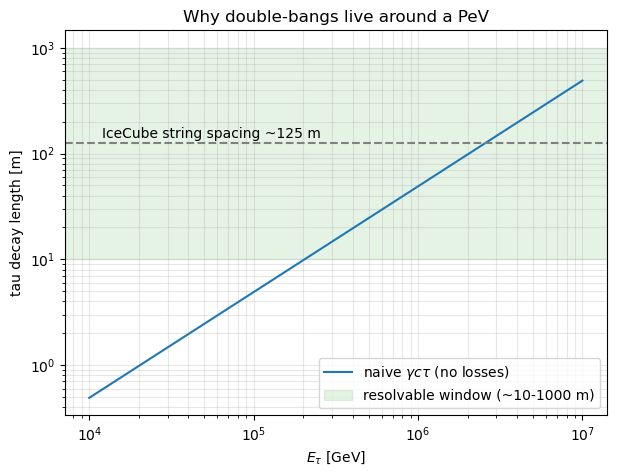

In [2]:
# Reference curve: naive mean decay length L = (E/m_tau)*c*tau (NO energy loss).
E_tau = np.logspace(4, 7, 100)                 # 10 TeV - 10 PeV
L_mean = H.tau_mean_decay_length_m(E_tau)

plt.figure(figsize=(7,5))
plt.loglog(E_tau, L_mean, label=r'naive $\gamma c\tau$ (no losses)')
plt.axhspan(10, 1000, alpha=.12, color='C2', label='resolvable window (~10-1000 m)')
plt.axhline(125, ls='--', color='grey')
plt.text(1.2e4, 140, 'IceCube string spacing ~125 m')
plt.xlabel(r'$E_\tau$ [GeV]'); plt.ylabel('tau decay length [m]')
plt.legend(); plt.title('Why double-bangs live around a PeV')
plt.grid(alpha=.3, which='both'); plt.show()


### Propagate real $\tau$ leptons with PROPOSAL

We build a minimal PROPOSAL propagator for the $\tau$ in **homogeneous ice** and propagate many
taus at each energy, recording the distance at which each one decays. This is *exactly* the API
Prometheus uses internally (`prometheus/lepton_propagation/new_proposal_lepton_propagator.py`),
reduced to a single medium so it runs in seconds.

PROPOSAL works in **MeV** and **cm**. Key calls (PROPOSAL ≥ 7):
`pp.particle.TauMinusDef()`, `pp.EnergyCutSettings`, `pp.crosssection.make_std_crosssection`,
`pp.PropagationUtility`, `pp.Propagator(pdef, [(geometry, utility, density)])`,
`prop.propagate(state, max_distance_cm)`, then `.track_propagated_distances()` for the decay
point and `.decay_products()` for the daughters.


In [3]:
def build_tau_propagator():
    'Minimal PROPOSAL tau propagator in homogeneous ice (one big sphere).'
    import proposal as pp
    GeV = 1e3                       # MeV per GeV
    pdef = pp.particle.TauMinusDef()
    medium = pp.medium.Ice()
    cuts = pp.EnergyCutSettings(0.5 * GeV, 1.0, True)   # ecut=0.5 GeV, vcut=1, cont.rand.
    cross = pp.crosssection.make_std_crosssection(pdef, medium, cuts, True)
    collection = pp.PropagationUtilityCollection()
    collection.displacement = pp.make_displacement(cross, True)
    collection.interaction  = pp.make_interaction(cross, True)
    collection.time         = pp.make_time(cross, pdef, True)
    collection.decay        = pp.make_decay(cross, pdef, True)   # << lets the tau DECAY
    utility = pp.PropagationUtility(collection=collection)
    geo = pp.geometry.Sphere(pp.Cartesian3D(0, 0, 0), 1e8, 0)   # 1000 km radius, in cm
    density = pp.density_distribution.density_homogeneous(1.0)   # use medium's own density
    return pp.Propagator(pdef, [(geo, utility, density)])

def propagate_taus(prop, energy_gev, n=300, max_m=1e5):
    'Return decay lengths [m] for n taus of given energy.'
    import proposal as pp
    GeV, m_to_cm, cm_to_m = 1e3, 100.0, 0.01
    out = []
    for _ in range(n):
        st = pp.particle.ParticleState()
        st.position  = pp.Cartesian3D(0, 0, 0)
        st.direction = pp.Cartesian3D(0, 0, 1)
        st.energy    = energy_gev * GeV
        sec = prop.propagate(st, max_m * m_to_cm)
        out.append(sec.track_propagated_distances()[-1] * cm_to_m)
    return np.array(out)

if H.have('proposal'):
    prop = build_tau_propagator()
    energies = np.array([1e5, 1e6, 1e7])        # 0.1, 1, 10 PeV
    decays = {E: propagate_taus(prop, E, n=300) for E in energies}
    print('propagated', sum(len(v) for v in decays.values()), 'taus')
else:
    decays = None
    print('proposal not installed -- run the Setup cell on Colab; '
          'the displays in Parts 2-3 still work from cached data.')


: 

In [1]:
# Decay-length distribution per energy band + median vs the naive gamma*c*tau curve.
if decays is not None:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    labels = {1e5:'0.1 PeV', 1e6:'1 PeV', 1e7:'10 PeV'}
    for E, L in decays.items():
        ax[0].hist(L, bins=np.logspace(-1, 4, 50), histtype='step',
                   density=True, label=labels[E])
    ax[0].axvspan(10, 1000, alpha=.12, color='C2')
    ax[0].set_xscale('log'); ax[0].set_xlabel('decay length [m]')
    ax[0].set_ylabel('pdf'); ax[0].legend(title=r'$E_\tau$')
    ax[0].set_title('PROPOSAL tau decay lengths')

    Es = np.array(sorted(decays))
    med = np.array([np.median(decays[E]) for E in Es])
    ax[1].loglog(Es, med, 'o-', label='PROPOSAL median')
    ax[1].loglog(E_tau, L_mean, 'k--', label=r'naive $\gamma c\tau$ (no losses)')
    ax[1].axhspan(10, 1000, alpha=.12, color='C2', label='resolvable window')
    ax[1].set_xlabel(r'$E_\tau$ [GeV]'); ax[1].set_ylabel('median decay length [m]')
    ax[1].legend(); ax[1].set_title('Real vs naive decay length')
    plt.tight_layout(); plt.show()
else:
    print('(skipped -- needs PROPOSAL; see Setup)')


NameError: name 'decays' is not defined

> **★ Discussion (Lecture 2 callback).** The naive $\gamma c\tau$ curve and PROPOSAL agree at
> low energy but the PROPOSAL median falls *below* it at the highest energies — the $\tau$'s
> stochastic energy losses bleed off energy (lowering $\gamma$) *before* it decays. Where does
> the median decay length cross the ~125 m string spacing? That energy is roughly where
> double-bangs become resolvable. Swap `TauMinusDef()` → `MuMinusDef()` and remove the decay
> term: the muon now **ranges out** instead of decaying — that is the "track" topology you'll
> see in Part 3.


---
## Part 2 — **Prometheus**: the full light + detector simulation

**Prometheus** is the open-source neutrino-telescope simulation. It chains the whole pipeline:

```
 injection (LeptonInjector/SIREN)  →  lepton propagation (PROPOSAL)
        →  Cherenkov light yield  →  photon propagation to modules  →  detected photons
```

The photon step has two backends: **PPC** (GPU, the IceCube-style path; `--with-ppc`) and
**olympus** (a CPU parametric path, slower per photon but GPU-free). The pre-generated
IceCube_HE data we use below was made with the **PPC** path on a GPU. Internally Prometheus is
driven by a nested config dict (`prometheus.config`) — `run.nevents`, `injection.name`,
`detector.geo file`, `photon propagator.name` — and you run it with `Prometheus().sim()`.

> **We do *not* run Prometheus in this notebook.** The full chain needs LeptonInjector + a
> photon backend (the heavy, conda-/GPU-built pieces) that don't import cleanly into a Colab
> kernel. Everything in Parts 2–3 loads the committed **pre-generated IceCube_HE** parquet, so
> nothing here depends on a live Prometheus install.
>
> **Want to run it yourself?** It's worth doing on a GPU box:
> - 📄 **Paper:** Prometheus, [arXiv:2304.14526](https://arxiv.org/abs/2304.14526)
> - 💻 **Code:** [github.com/Harvard-Neutrino/prometheus](https://github.com/Harvard-Neutrino/prometheus)
> - 📚 **Docs:** [harvard-neutrino.github.io/prometheus](https://harvard-neutrino.github.io/prometheus/)


### A hand-picked $\nu_\tau$ double-bang

The committed `data/Prometheus_simulation/IceCube_HE/<signature>/Generation_*_photons.parquet`
files are **real Prometheus output**. Each file is an `awkward` array, one record per event:

- `mc_truth` — the injected truth: `initial_state_type`/`energy`, the interaction vertex
  (`initial_state_x/y/z`) and direction (`initial_state_zenith/azimuth`), `interaction`
  (1 = CC, 2 = NC), `final_state_*`, `bjorken_x/y`, …
- `photons` — **one entry per detected photon**: `sensor_pos_x/y/z` (the module it hit),
  `string_id`, `sensor_id`, `t` (arrival time, ns).

`helpers.load_prometheus_event` reads this schema, collapses photons to **one dot per module**
(charge = photon count, time = earliest arrival), and returns a tidy `info` dict of the truth.
We start with a **hand-picked $\nu_\tau$ CC event** (index `774` in the `TauMinus` file) — a
clean **double-bang**: the $\tau$ is made at the vertex (first cascade), flies, then decays
(second cascade).


In [ ]:
# The four IceCube_HE signatures live one folder each; load the hand-picked tau event.
DATA = 'data/Prometheus_simulation/IceCube_HE'
TAU  = f'{DATA}/TauMinus/Generation_00000-000_photons.parquet'
HERO_TAU = 774                                  # hand-picked clean double-bang

hits, geo, info = H.load_prometheus_event(TAU, event=HERO_TAU)
print(f"event {info['event_index']}: {info['class_label']}, "
      f"E = {info['initial_state_energy_gev']:.2e} GeV,  Bjorken-y = {info['bjorken_y']:.2f}")
print(f"{info['n_photons']} photons on {info['n_modules_hit']} modules")


In [ ]:
# Display the double-bang, coloured by CHARGE (photons/module) so the two cascades pop.
# add_truth_overlay marks the interaction vertex (red star) + travel direction (arrow)
# and the two MC-truth cascade points (magenta stars).
ax = H.plot_event_display(hits, geo=geo, color_by='npe',
                          title=r'IceCube_HE $\nu_\tau$ CC double-bang (event 774)')
H.add_truth_overlay(ax, info)
ax.legend(loc='upper left', fontsize=8)
plt.show()


### Why this event? Screening the $\tau$ decay length

Most $\nu_\tau$ events are **not** clean double-bangs — at these energies the two cascades are
usually too close to resolve. We picked event 774 by computing, for every event in the
`TauMinus` file, the distance between the **first cascade** (the $\tau$ production vertex,
`final_state_*[-1]`) and the **second cascade** (the $\tau$ decay, `final_state_*[1]`), and
looking for a well-separated, well-lit one. The histogram below is the same
$\gamma c\tau$-driven decay-length distribution from Part 1 — now read straight off the
Prometheus truth — with event 774 marked.


In [ ]:
# Decay length = distance between the two cascades, for every event in the TauMinus file.
import awkward as ak  # noqa: PLC0415

arr = ak.from_parquet(TAU)
vtx   = np.stack([ak.to_numpy(arr.mc_truth.final_state_x[:, -1]),   # tau production
                  ak.to_numpy(arr.mc_truth.final_state_y[:, -1]),
                  ak.to_numpy(arr.mc_truth.final_state_z[:, -1])], axis=1)
decay = np.stack([ak.to_numpy(arr.mc_truth.final_state_x[:, 1]),    # tau decay
                  ak.to_numpy(arr.mc_truth.final_state_y[:, 1]),
                  ak.to_numpy(arr.mc_truth.final_state_z[:, 1])], axis=1)
decay_length = np.sqrt(((vtx - decay) ** 2).sum(axis=1))

plt.figure(figsize=(7, 4.5))
plt.hist(decay_length, bins=np.logspace(-3, 3, 30), histtype='step', lw=1.5)
plt.axvspan(10, 1000, alpha=.12, color='C2', label='resolvable window (~10-1000 m)')
plt.axvline(125, ls='--', color='grey', label='IceCube string spacing ~125 m')
plt.axvline(decay_length[HERO_TAU], color='C3', lw=2,
            label=f'event {HERO_TAU} ({decay_length[HERO_TAU]:.0f} m)')
plt.xscale('log'); plt.xlabel('tau decay length [m]'); plt.ylabel('events')
plt.title('Prometheus $\\nu_\\tau$ decay lengths (truth)'); plt.legend(fontsize=8)
plt.show()


---
## Part 3 — The signature zoo (Lecture 2 callback)

Same machinery, different final states → different **topologies**. With truth-labelled
Prometheus output we render each one and read off how well each reconstructs energy vs direction:

| Signature | Origin | Topology | Energy reco | Direction reco |
|---|---|---|---|---|
| **Cascade** | $\nu_e$ CC, all NC | compact blob | **good** (calorimetric, contained) | poor |
| **Track** | $\nu_\mu$ CC (muon exits) | long line | poor (only $dE/dx$ lower bound) | **good** (lever arm) |
| **Double bang** | $\nu_\tau$ CC | two blobs | good if both contained | medium |

Below: the four IceCube_HE signatures side by side. Watch the **time colour** (early = red): a
track shows a clear early→late gradient along the muon's path; a cascade lights up almost at once.


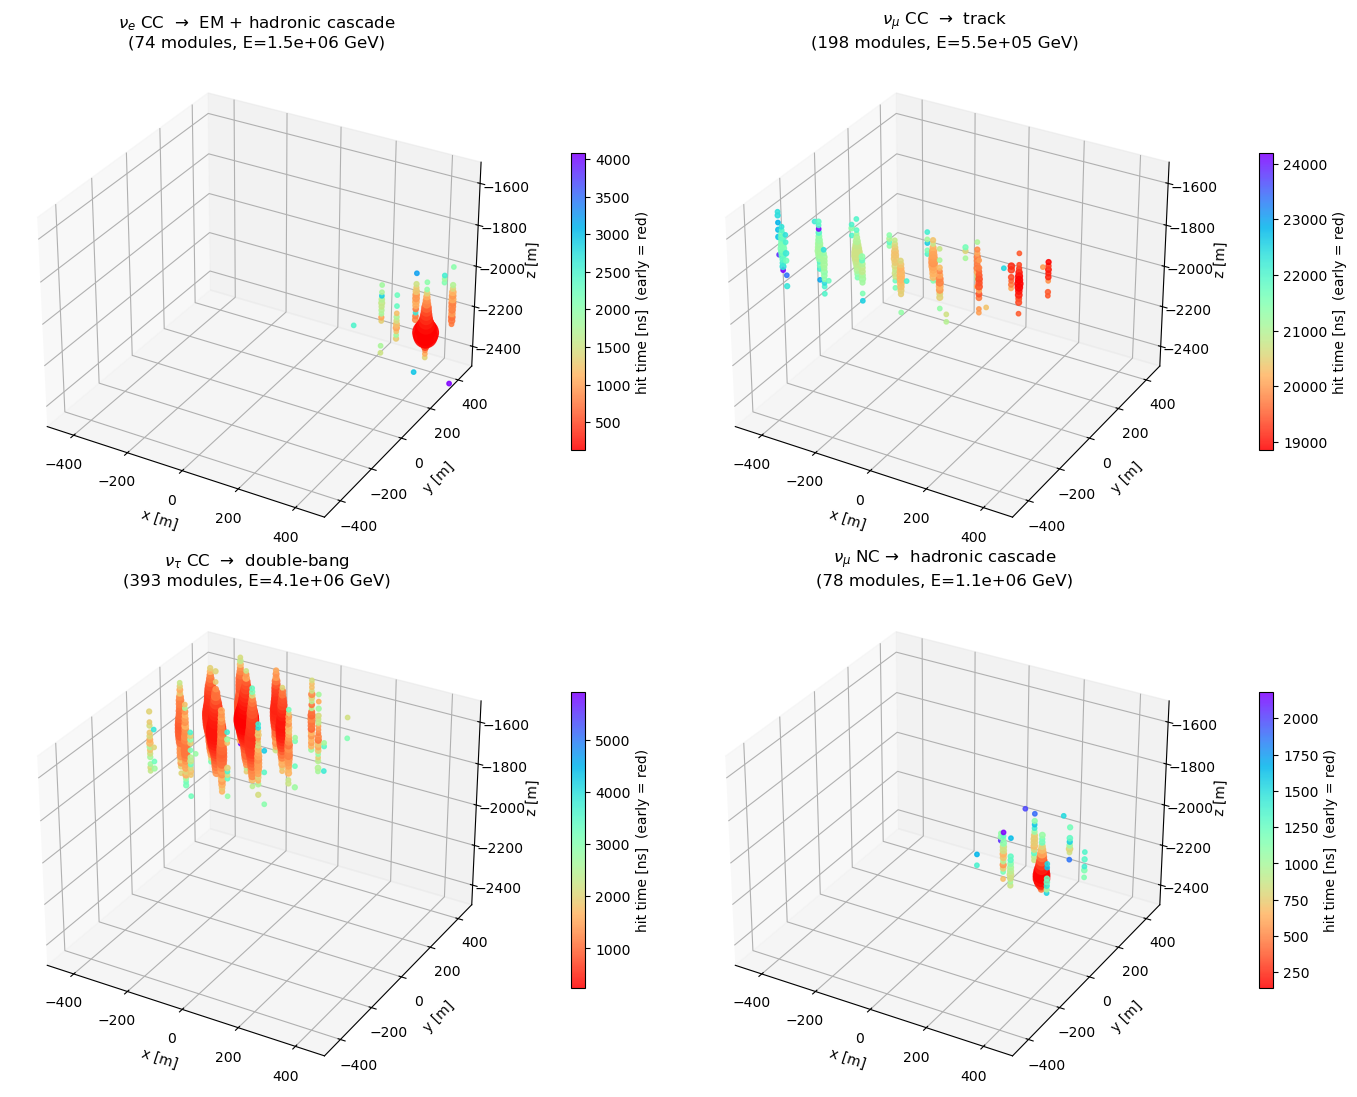

In [72]:
SIGS = [
    ('EMinus',   r'$\nu_e$ CC  →  EM + hadronic cascade', 14),
    ('MuMinus',  r'$\nu_\mu$ CC  →  track', 9),
    ('TauMinus', r'$\nu_\tau$ CC  →  double-bang', 774),
    ('NuMu',     r'$\nu_\mu$ NC →  hadronic cascade', 30),
]
fig = plt.figure(figsize=(14, 11))
for i, (sig, title, event_id) in enumerate(SIGS):
    path = f'data/Prometheus_simulation/IceCube_HE/{sig}/Generation_00000-000_photons.parquet'
    hits, geo, info = H.load_prometheus_event(path, event=event_id)

    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    H.plot_event_display(hits, ax=ax, geo=geo,
                         title=f"{title}\n({info['n_modules_hit']} modules, "
                               f"E={info['initial_state_energy_gev']:.1e} GeV)")
plt.tight_layout(); plt.show()


### A closer look: what each optical module records

The event display shows **one dot per module**, but each module actually records a full
**waveform** — the arrival-time distribution of all the photons that reached it. This is the
raw quantity reconstruction algorithms work from. For our double-bang (event 774), the
brightest modules sit *between* the two cascades, so many of them see **two clusters** in time:
an early one from the production cascade and a later one from the $\tau$ decay. The grid below
plots the arrival-time histogram for the brightest modules (via `H.dom_waveforms`).


In [ ]:
# Per-DOM waveforms for the brightest modules of the tau double-bang (event 774).
waveforms = H.dom_waveforms(TAU, HERO_TAU, n_brightest=12)

fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
bins = np.linspace(0, 2000, 100)
for wf, ax in zip(waveforms, axes.ravel()):
    ax.hist(wf['times'], bins=bins, color='C0')
    ax.set_title(f"string {wf['string_id']}, sensor {wf['sensor_id']}  "
                 f"({wf['n_photons']} ph)", fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes[-1]:
    ax.set_xlabel('photon arrival time [ns]', fontsize=8)
fig.suptitle('Per-module waveforms — many show two time clusters (the two cascades)')
plt.tight_layout(); plt.show()


---
## ★ Play: guess the event

Now you're the reconstruction algorithm. Run the cell below to draw a **random IceCube_HE
event** with the truth hidden. Using everything from Lecture 2 and the zoo above:

1. **Guess the class** — is it a $\nu_e$ CC (compact cascade), $\nu_\mu$ CC (long track),
   $\nu_\tau$ CC (double-bang), or an **NC** (cascade, any flavour)? Look at the *shape* and
   the **time colour** (early = red): tracks show a clear early→late gradient, cascades light
   up almost at once.
2. **Guess the energy** — more light / more modules ⇒ higher energy (these span roughly
   **TeV–PeV**, $\sim 10^3$–$10^7$ GeV).

Then hit **Reveal answer**: it prints the true class and energy and overlays the interaction
**vertex** (red star) and **direction arrow**. **New event** deals another one.


In [ ]:
# === "Guess the event" game =========================================================
# Pulls a random IceCube_HE event (with enough light to see), hides the truth, and lets
# you reveal it. Make your guess out loud first: which class, and roughly what energy?
import ipywidgets as widgets                      # noqa: PLC0415
from IPython.display import display               # noqa: PLC0415

_game = {}

def _draw(reveal):
    info = _game['info']
    _out.clear_output(wait=True)
    with _out:
        title = ('MYSTERY EVENT — guess the class (nu_e CC / nu_mu CC / nu_tau CC / NC)'
                 ' and the energy!')
        ax = H.plot_event_display(_game['hits'], geo=_game['geo'], color_by='t',
                                  title=title)
        if reveal:
            # vertex + direction arrow; cascade stars only meaningful for the tau
            H.add_truth_overlay(ax, info,
                                show_cascades=(info['class_label'] == 'nu_tau CC'))
            ax.set_title(f"{info['class_label']}    "
                         f"E = {info['initial_state_energy_gev']:.2e} GeV")
            ax.legend(loc='upper left', fontsize=8)
            print(f"  Answer : {info['class_label']}")
            print(f"  Energy : {info['initial_state_energy_gev']:.3e} GeV")
        plt.show()

def _new_event(_=None):
    path, idx = H.pick_random_event('IceCube_HE', min_photons=50)
    hits, geo, info = H.load_prometheus_event(path, event=idx)
    _game.update(path=path, idx=idx, hits=hits, geo=geo, info=info)
    _draw(reveal=False)

_new_btn = widgets.Button(description='New event', button_style='info', icon='random')
_reveal_btn = widgets.Button(description='Reveal answer', button_style='success', icon='eye')
_new_btn.on_click(_new_event)
_reveal_btn.on_click(lambda _: _draw(reveal=True))
_out = widgets.Output()
display(widgets.HBox([_new_btn, _reveal_btn]), _out)
_new_event()


## ★ Discussion questions & exercises

1. **Decay-length crossover (Part 1).** At what $E_\tau$ does the PROPOSAL median decay length
   cross the ~125 m IceCube string spacing? Relate that to where real IceCube tau searches live
   (~PeV). Why does raising the resolvable-window lower edge (10 m → 30 m, i.e. worse vertex
   resolution) shrink the double-bang energy range?

2. **Stochastic losses (Lecture 2).** Re-run `propagate_taus` at $E_\tau = 10$ PeV with many
   taus and overlay the distribution against the single naive $\gamma c\tau$ value. The spread
   *is* the stochasticity of bremsstrahlung/pair/photonuclear losses. Now switch to
   `MuMinusDef()` (drop `collection.decay`): the muon **ranges out** — measure its range vs
   energy and compare to the muon **critical energy** (~0.5 TeV in ice).

3. **Cascade vs. track reconstruction (Part 3).** From the displays, argue why a contained
   **cascade** gives the best *energy* resolution but poor *direction*, while a **through-going
   track** gives the best *direction* but only a *lower bound* on energy. Which signature is best
   for a diffuse astrophysical flux measurement? For point-source searches?

4. **Connect the notebooks.** The $\nu_\tau$ injected by SIREN in notebook 1 → the decay length
   from PROPOSAL here → the double-bang display. Predict a tau's topology from its energy
   *before* plotting it: low-E taus give a merged single cascade (looks like a $\nu_e$), high-E
   ones two resolved bangs.

5. **Pipeline.** Identify which Prometheus config key controls each pipeline stage
   (`injection.name`, `lepton propagator.name`, `photon propagator.name`,
   `detector.geo file`). Which would you change to (a) simulate ARCA instead of IceCube,
   (b) switch the photon path from GPU PPC to CPU olympus?

---
**References:** Prometheus (arXiv:2304.14526), SIREN / LeptonInjector (arXiv:2012.10449),
PROPOSAL (Koehne et al., Comput. Phys. Commun. 2013; Dunsch et al. 2019),
Formaggio & Zeller (Rev. Mod. Phys. 2012).
